# 6. Atsitiktinis miškas (planas M4, H2 atskaita)

**Failas:** `winequality/forest.py` → `forest_pipeline`  
**Mokymas:** `winequality/tune.py` → `tune_rf`

Medžių ansamblis — stipri lentelinių duomenų atskaita. Plane: jei RF pranoksta SVR
daugiau nei 0,02 MAE **ir** reikšmingai, diegiamas RF (blokas 6b). Kitaip lieka SVR.


## Taisyklė (regresijos medis ir ansamblis)

Vienas medis skaido požymių erdvę stačiakampiais \(R_m\) ir kiekviename lapelyje
prognozuoja mokymo atsakymų vidurkį:

\[
T(\mathbf{x}) = \sum_{m=1}^{M} \bar y_{R_m}\, \mathbf{1}[\mathbf{x}\in R_m]
\]

Miškas vidurkina \(B\) medžių, kiekvienas mokomas bootstrap imties ir atsitiktinio požymių poaibio:

\[
f(\mathbf{x}) = \frac{1}{B}\sum_{b=1}^{B} T_b(\mathbf{x})
\]

Todėl prognozė **laiptuota** ir neekstrapoliuoja už mokymo min/max — SVR pranašumas ordinaliniam balui.


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = here if (here / "winequality").exists() else here.parent
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "notebooks"))

from nb_pagalba import paruošti, metrikos_lentele, artefaktas
from winequality.config import FEATURE_NAMES, SPLIT_SEED

KIND = "red"  # pakeiskite į "white", jei norite balto vyno
duom = paruošti(KIND)
X_tr, y_tr, X_te, y_te = duom["X_tr"], duom["y_tr"], duom["X_te"], duom["y_te"]
print(f"{KIND}: mokymo n={duom['n_train']}, testo n={duom['n_test']}, sėkla={SPLIT_SEED}")
print("Požymiai:", FEATURE_NAMES)


red: mokymo n=1279, testo n=320, sėkla=0
Požymiai: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


Įkeltas artefaktas: rf_red.joblib
medžių B = 400   max_depth = None
unikalios prognozės teste: 225


,modelis,MAE,MAE (apvalinta),Acc_0.5,Acc_1.0,κ_w,makro-F1
0,atsitiktinis miškas,0.4845,0.4125,0.6031,0.8906,0.5952,0.5484


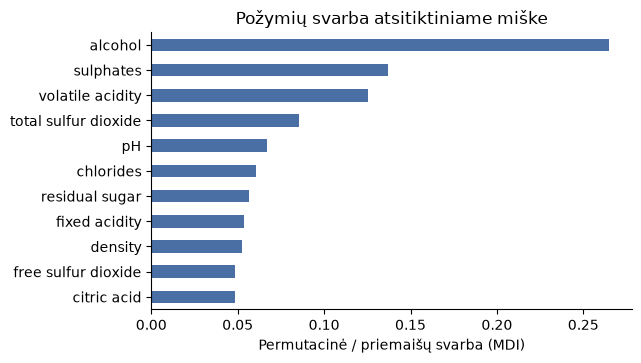

In [2]:
import joblib
from winequality.forest import forest_pipeline

kelias = artefaktas("rf", KIND)
if kelias.exists():
    vamzdis = joblib.load(kelias)
    print("Įkeltas artefaktas:", kelias.name)
else:
    vamzdis = forest_pipeline(n_estimators=200, max_depth=12, seed=0)
    vamzdis.fit(X_tr, y_tr)

rf = vamzdis.named_steps["rf"]
f = vamzdis.predict(X_te)
print("medžių B =", rf.n_estimators, "  max_depth =", rf.max_depth)
print("unikalios prognozės teste:", len(np.unique(np.round(f, 5))))

lentele = metrikos_lentele(y_te, f, "atsitiktinis miškas")
display(lentele.round(4))

svarba = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(6.2, 3.6))
svarba.plot.barh(ax=ax, color="#4a6fa5")
ax.set_xlabel("Permutacinė / priemaišų svarba (MDI)")
ax.set_title("Požymių svarba atsitiktiniame miške")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Ką stebėti

- H2: \(\mathrm{MAE}_{SVR} - \mathrm{MAE}_{RF} \le 0{,}02\) — **galioja abiem** vyno tipams.
- Baltam vynui RF truputį geresnis MAE (0,532 vs 0,534), bet skirtumas << 0,02, todėl pagrindinis metodas lieka SVR.
- Svarbiausias požymis paprastai **alkoholis**; lakiosios rūgštys svarbesnės raudonam vynui.
